# Deconvolved Data Replication Timing from 10k MNase-seq Windows

April 24, 2024

Compute the replicating timing from the deconvolved MNase-seq 10k windows for each gene.

This will require a tuning of the alpha parameter.


In [2]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
from src.mnase_replication_timing_analysis import MNaseOriginAnalysis

mnase_analysis_rep1 = MNaseOriginAnalysis(replicate=1)
mnase_analysis_rep1.compute_bin_curves_and_expression_correlations()
mnase_analysis_rep1.compute_replication_timing()

1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 00:02:15.976


In [90]:
mnase_analysis_rep2 = MNaseOriginAnalysis(replicate=2)
mnase_analysis_rep2.compute_bin_curves()


In [95]:
mnase_analysis_rep2.compute_replication_timing()

In [97]:
mnase_analysis_rep1.load_posteriors_for_timing()
mnase_analysis_rep2.load_posteriors_for_timing()

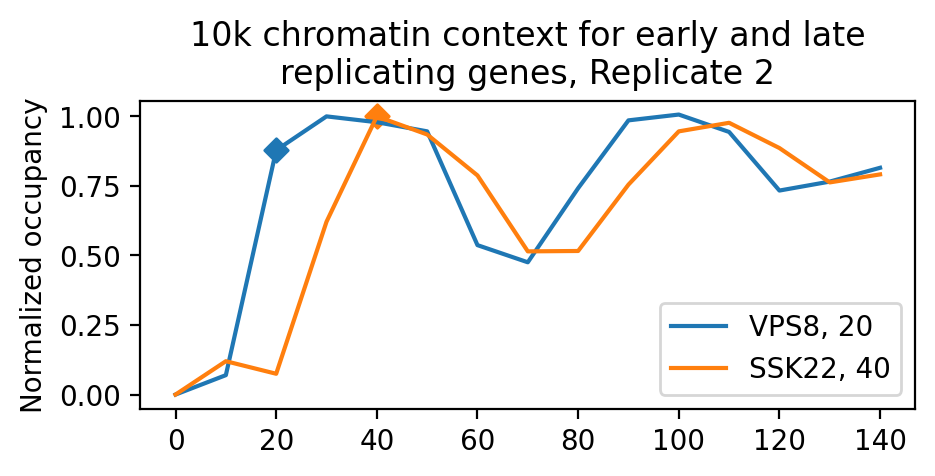

In [98]:
mnase_analysis_rep2.plot_normalized_bin_curves(['VPS8', 'SSK22'])

In [99]:
from src.deconv_replication_timing import DeconvReplicationProfileAnalysis

deconv_rep_analysis1 = DeconvReplicationProfileAnalysis(mnase_analysis_rep1, mnase_analysis_rep2)
deconv_rep_analysis2 = DeconvReplicationProfileAnalysis(mnase_analysis_rep1, mnase_analysis_rep2)

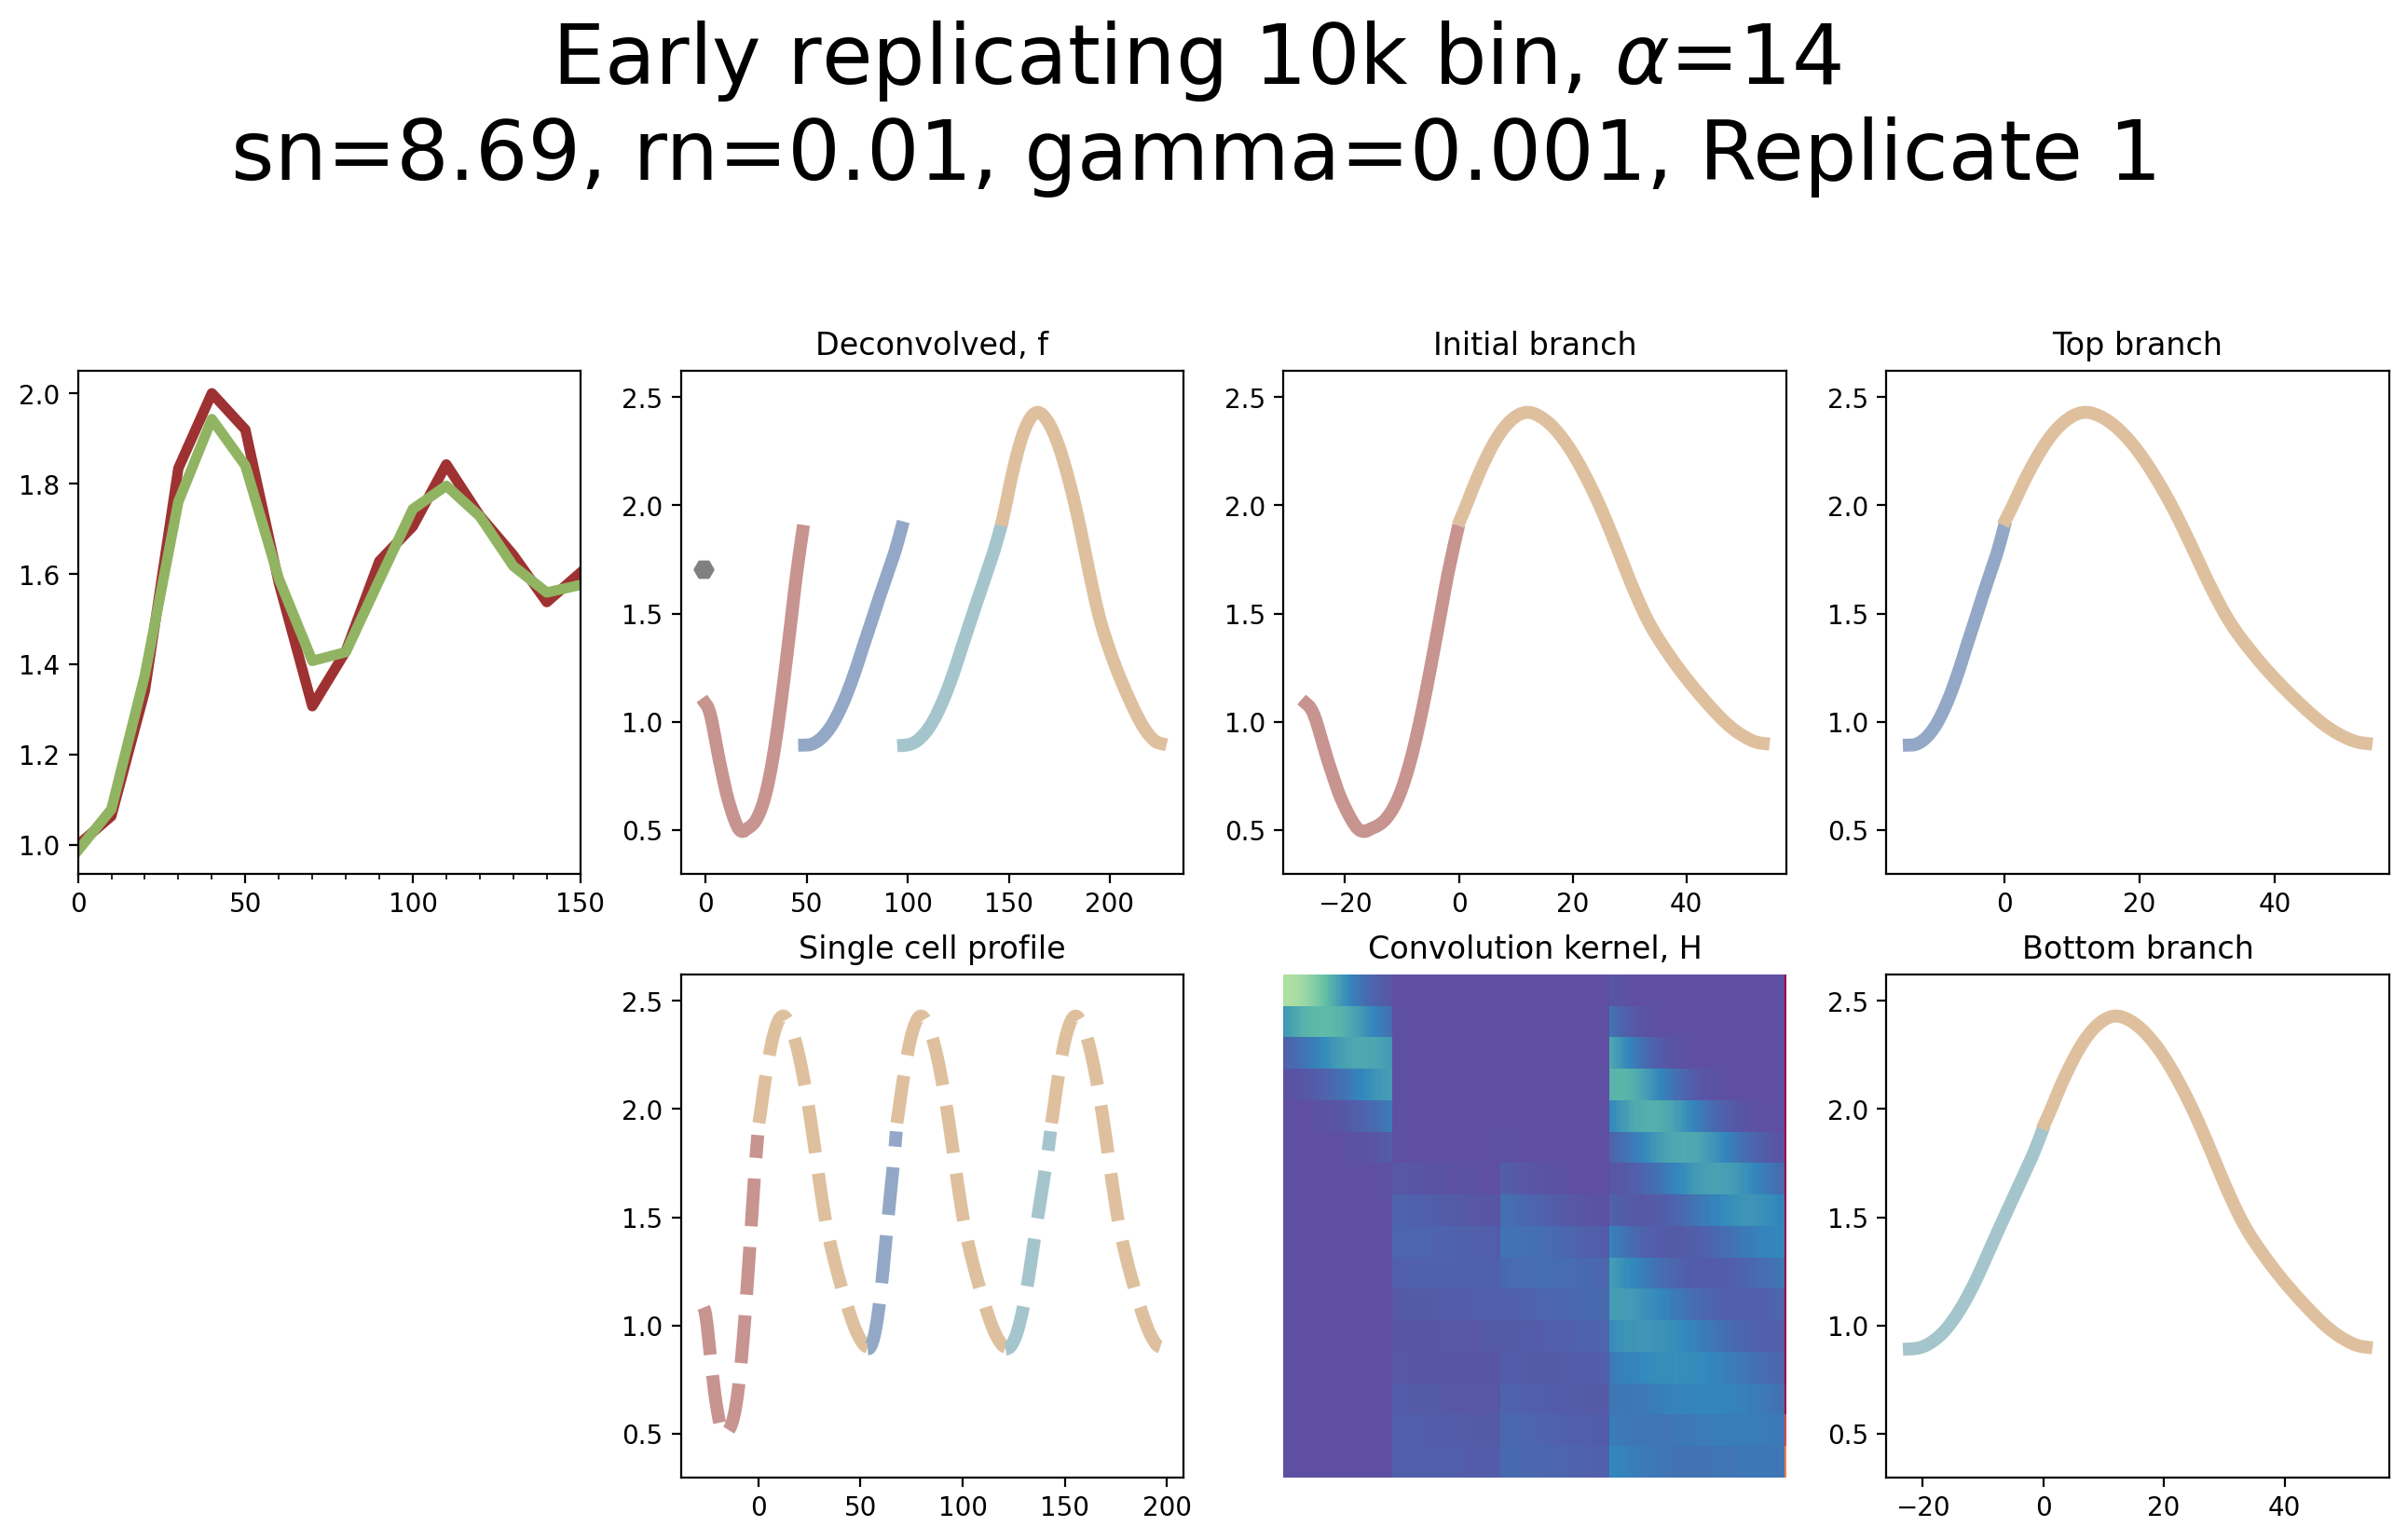

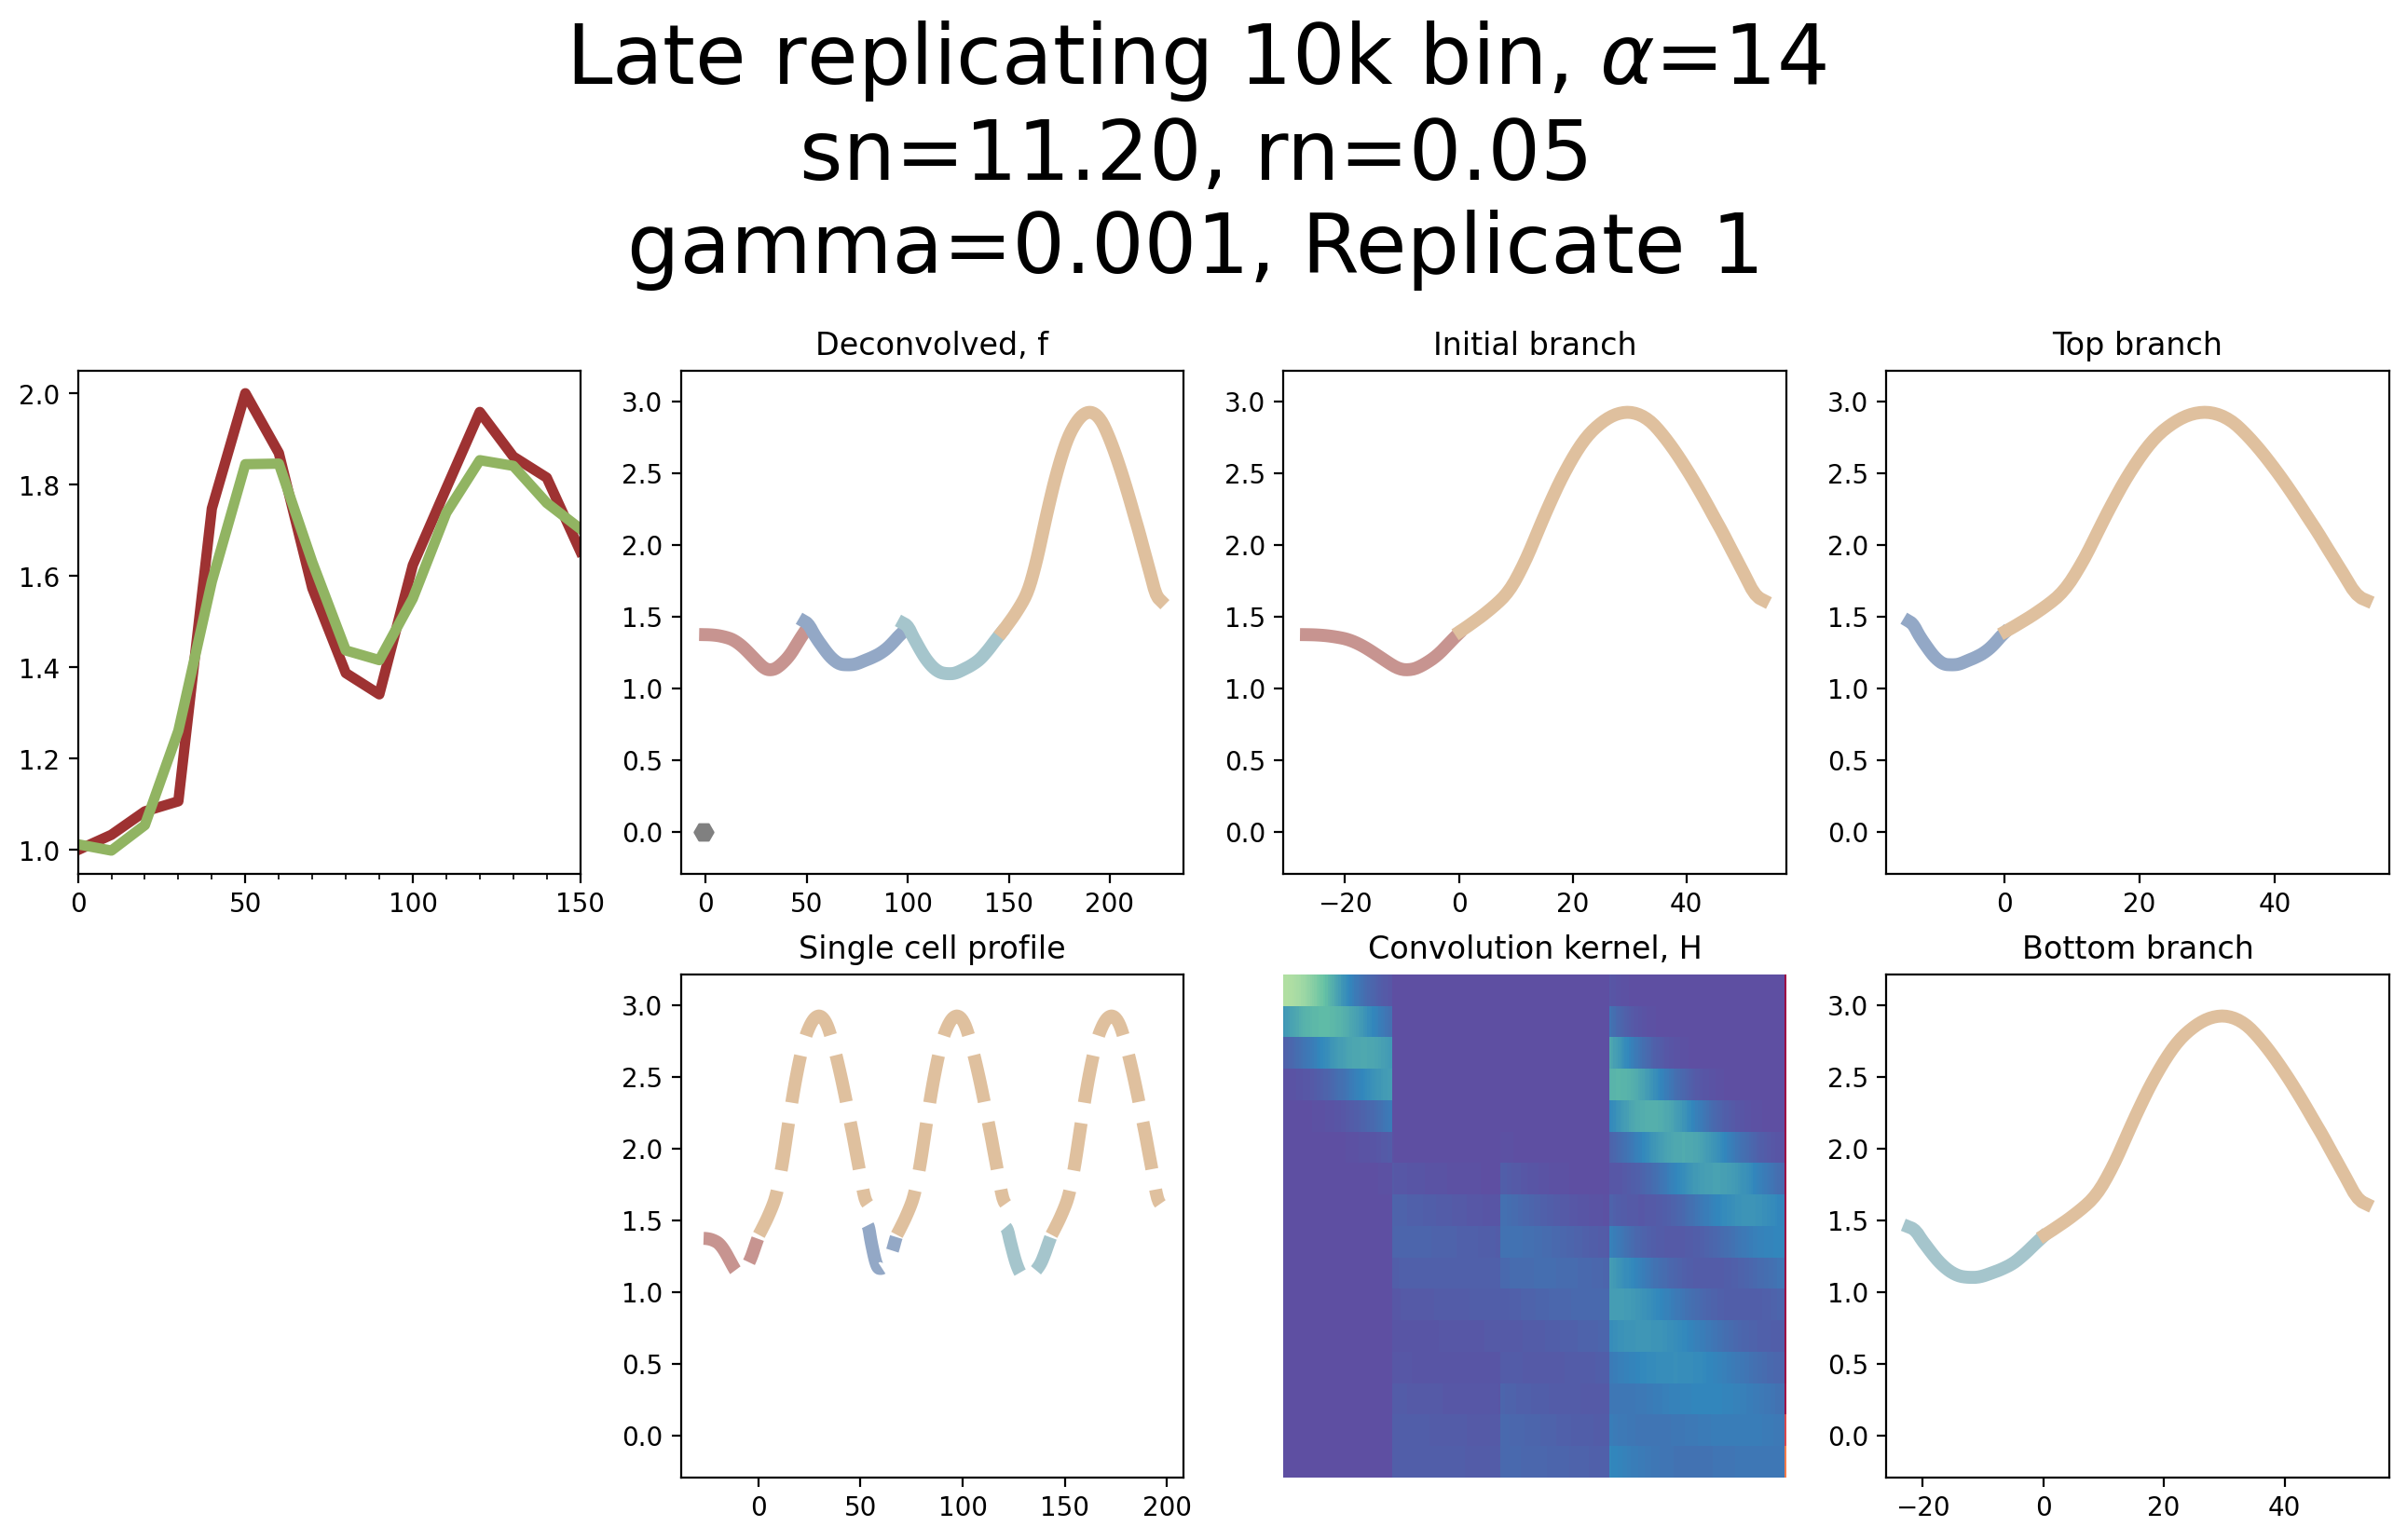

In [57]:
deconv_rep_analysis1.compare_early_late_deconv_bin_curves(14, 1)

In [102]:
deconv_rep_analysis1.create_chr_bin_curves(1, 4)
deconv_rep_analysis2.create_chr_bin_curves(2, 4)

Setting up bin curves for replicate 1, chromosome 4
Setting up model with temporary gene. (Actual deconvolution will use chrom bin curves, not gene data)...
Loading MNase reads for YMR199W/CLN1...Loading chromosome reads: 13
Done.
Setting up bin curves for replicate 2, chromosome 4
Setting up model with temporary gene. (Actual deconvolution will use chrom bin curves, not gene data)...
Loading MNase reads for YMR199W/CLN1...Loading chromosome reads: 13
Done.


In [140]:
deconv_rep_analysis1.alpha_search(alphas=np.arange(0, 32, 1))

0/32, alpha=0
Deconvolving with gamma=0.001, gamma_prime=0
Deconvolved in : 00:01:53.430
The fitting norm is 0.11, the smoothing norm is: 19.47
00:01:53.976
1/32, alpha=1
Deconvolving with gamma=0.001, gamma_prime=0
Deconvolved in : 00:01:45.976
The fitting norm is 0.13, the smoothing norm is: 18.00
00:03:40.602
2/32, alpha=2
Deconvolving with gamma=0.001, gamma_prime=0
Deconvolved in : 00:02:07.190
The fitting norm is 0.13, the smoothing norm is: 17.63
00:05:48.625
3/32, alpha=3
Deconvolving with gamma=0.001, gamma_prime=0
Deconvolved in : 00:02:00.131
The fitting norm is 0.11, the smoothing norm is: 18.02
00:07:49.360
4/32, alpha=4
Deconvolving with gamma=0.001, gamma_prime=0
Deconvolved in : 00:01:56.727
The fitting norm is 0.12, the smoothing norm is: 17.00
00:09:46.708
5/32, alpha=5
Deconvolving with gamma=0.001, gamma_prime=0
Deconvolved in : 00:02:00.587
The fitting norm is 0.12, the smoothing norm is: 16.73
00:11:47.890
6/32, alpha=6
Deconvolving with gamma=0.001, gamma_prime=0

In [141]:
deconv_rep_analysis2.alpha_search(alphas=np.arange(0, 32, 1))

0/32, alpha=0
Deconvolving with gamma=0.001, gamma_prime=0
Deconvolved in : 00:34:09.856
The fitting norm is 0.11, the smoothing norm is: 18.39
00:34:10.493
1/32, alpha=1
Deconvolving with gamma=0.001, gamma_prime=0
Deconvolved in : 03:52:06.595
The fitting norm is 0.12, the smoothing norm is: 18.18
04:26:17.694
2/32, alpha=2
Deconvolving with gamma=0.001, gamma_prime=0
Deconvolved in : 00:01:51.123
The fitting norm is 0.11, the smoothing norm is: 17.85
04:28:09.422
3/32, alpha=3
Deconvolving with gamma=0.001, gamma_prime=0
Deconvolved in : 00:01:44.209
The fitting norm is 0.12, the smoothing norm is: 17.66
04:29:54.190
4/32, alpha=4
Deconvolving with gamma=0.001, gamma_prime=0
Deconvolved in : 00:01:47.947
The fitting norm is 0.11, the smoothing norm is: 17.24
04:31:42.736
5/32, alpha=5
Deconvolving with gamma=0.001, gamma_prime=0
Deconvolved in : 00:01:48.717
The fitting norm is 0.10, the smoothing norm is: 16.96
04:33:32.059
6/32, alpha=6
Deconvolving with gamma=0.001, gamma_prime=0

In [142]:
pd.DataFrame(deconv_rep_analysis1.alphas).to_csv("output/alpha_search_mnase/rep1_alpha.csv")
pd.DataFrame(deconv_rep_analysis2.alphas).to_csv("output/alpha_search_mnase/rep2_alpha.csv")

In [143]:
np.save("output/alpha_search_mnase/rep1_alpha_fs.npy", deconv_rep_analysis1.alpha_fs)
np.save("output/alpha_search_mnase/rep2_alpha_fs.npy", deconv_rep_analysis2.alpha_fs)

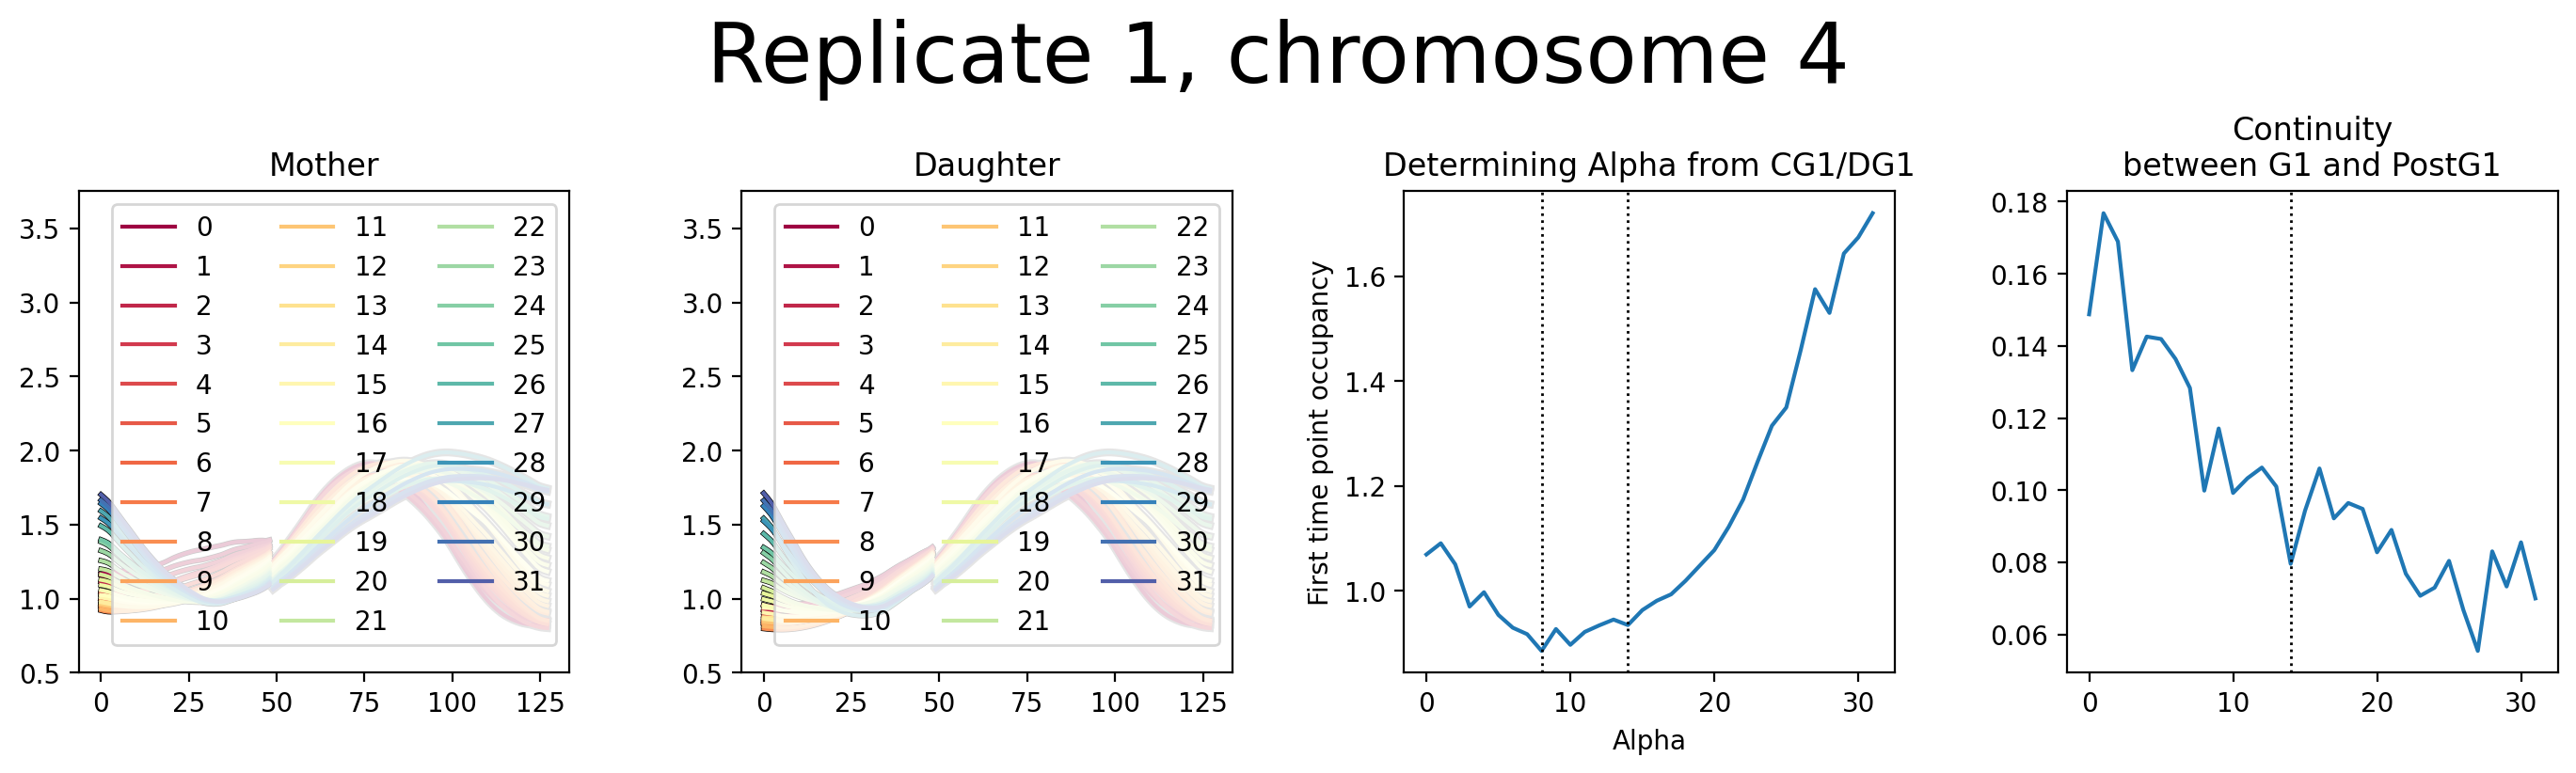

In [144]:
deconv_rep_analysis1.plot_alpha_search_results()

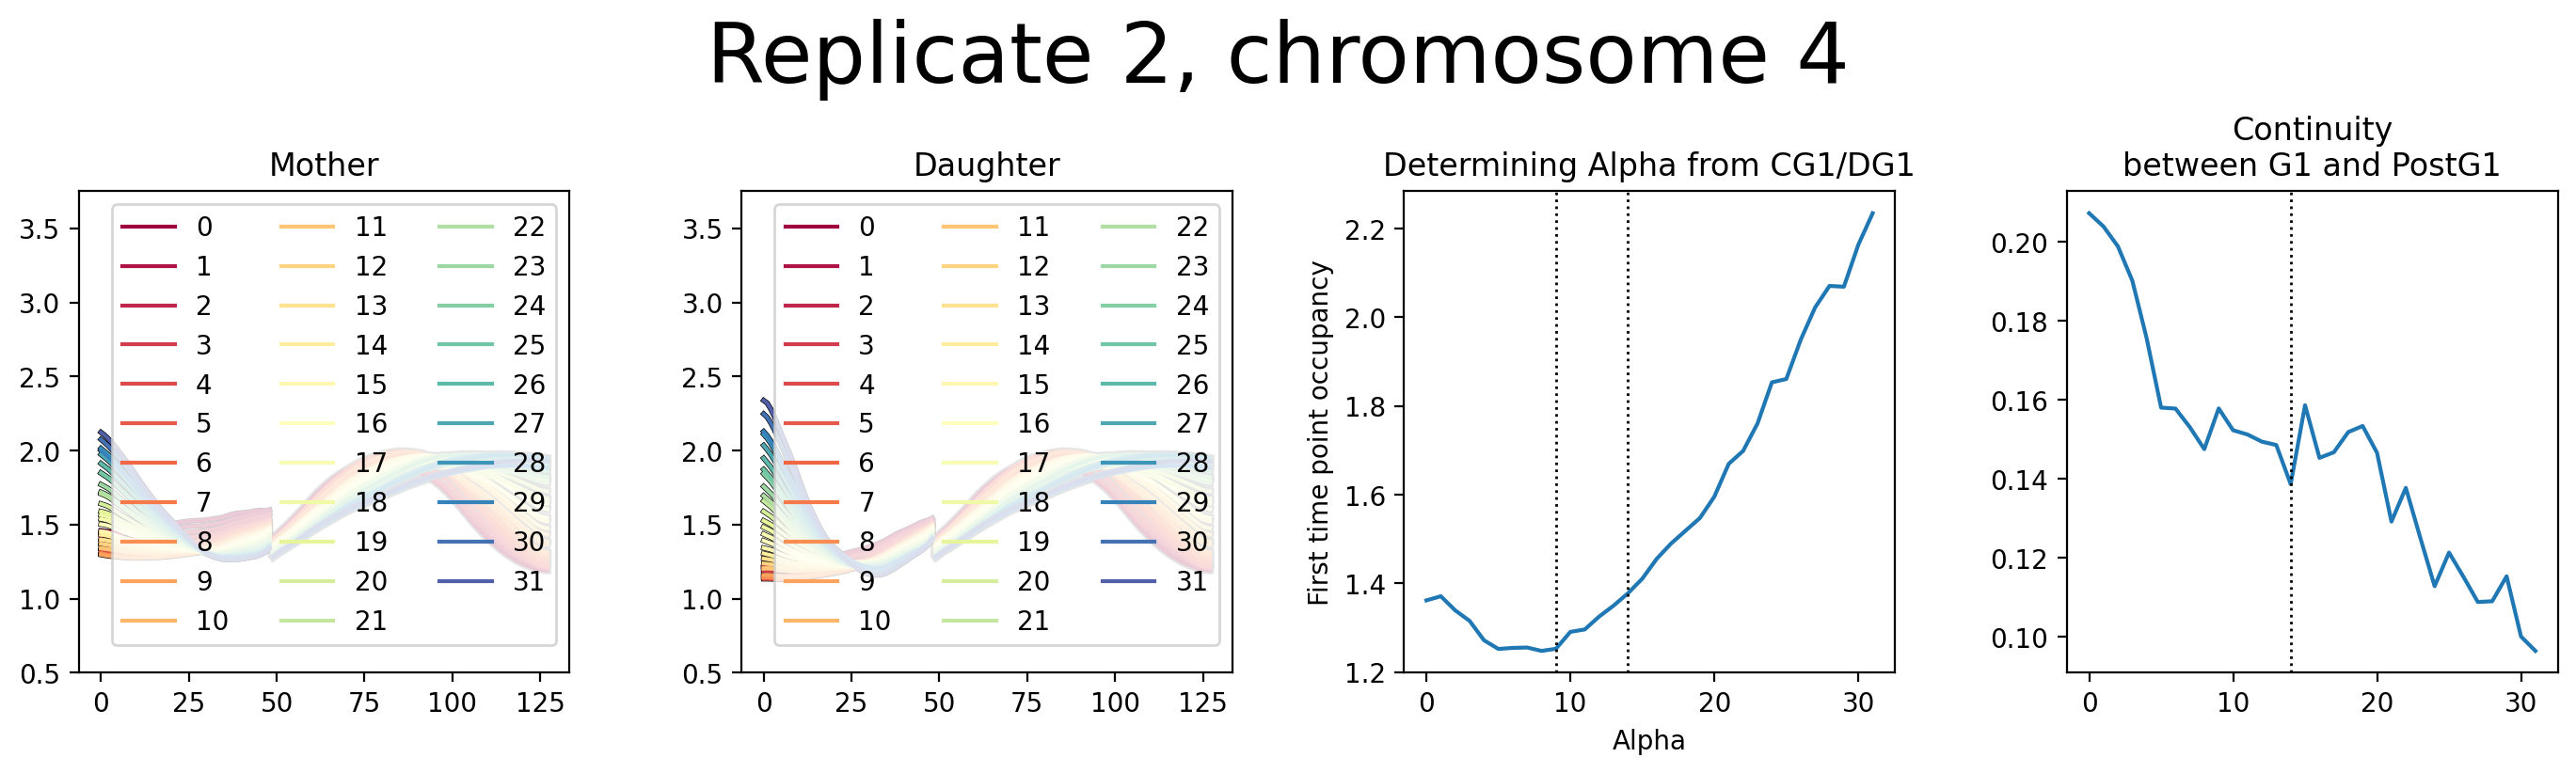

In [145]:
deconv_rep_analysis2.plot_alpha_search_results()

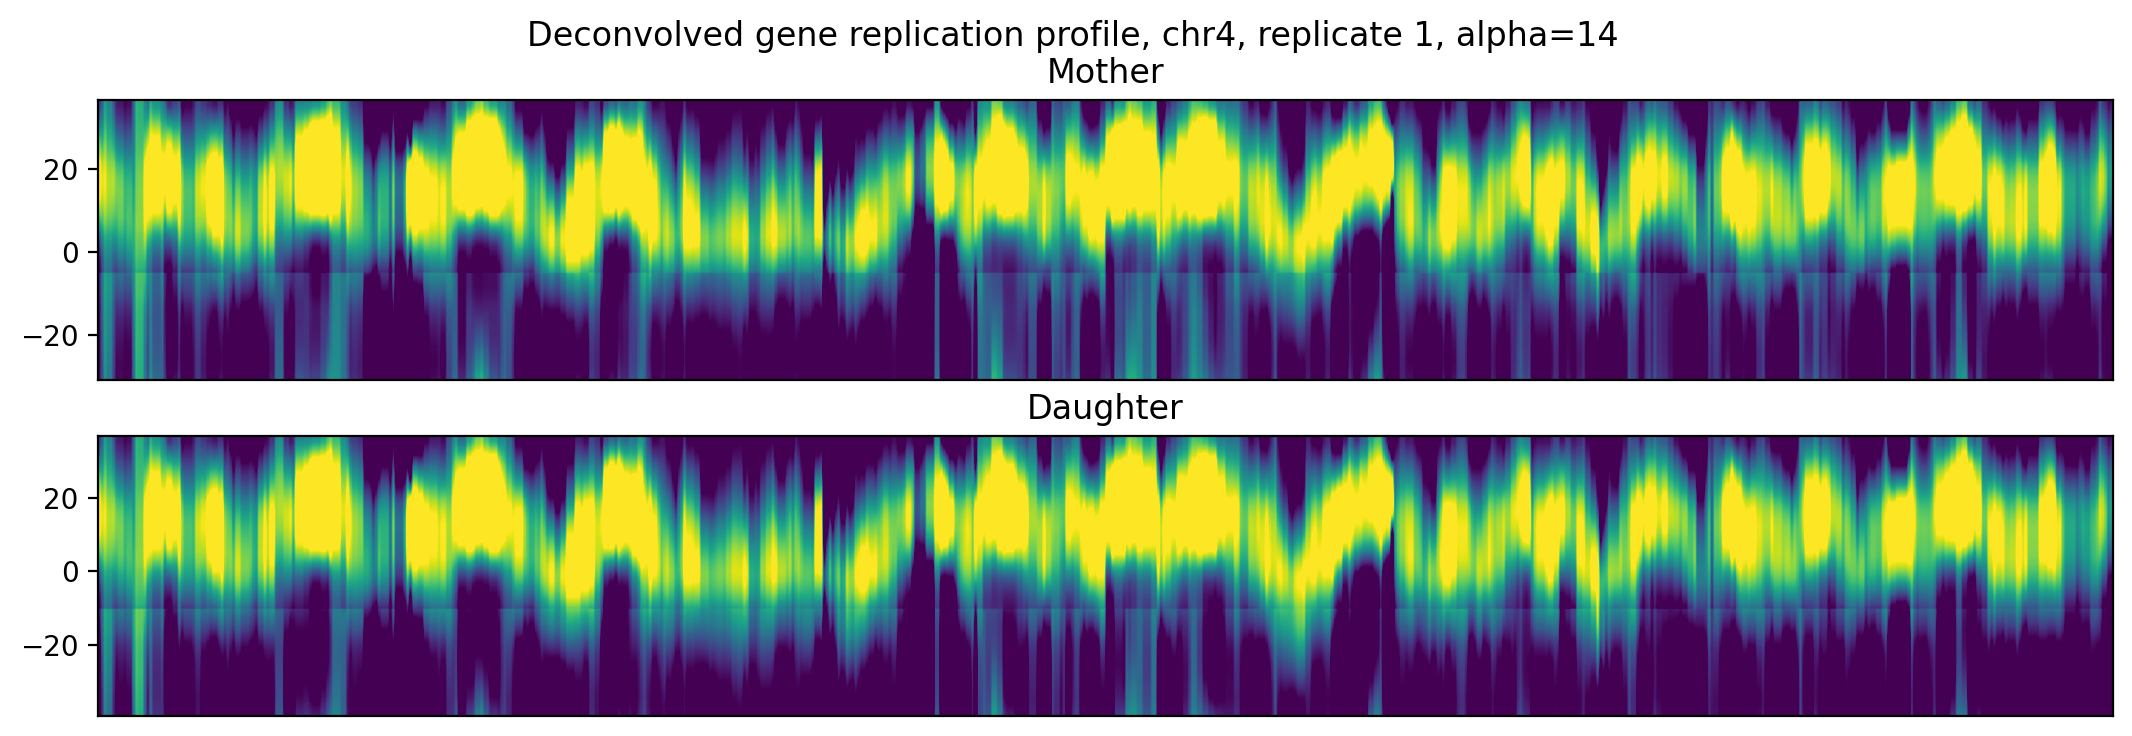

In [149]:
deconv_rep_analysis1.plot_example_alpha_repl_timing(14)

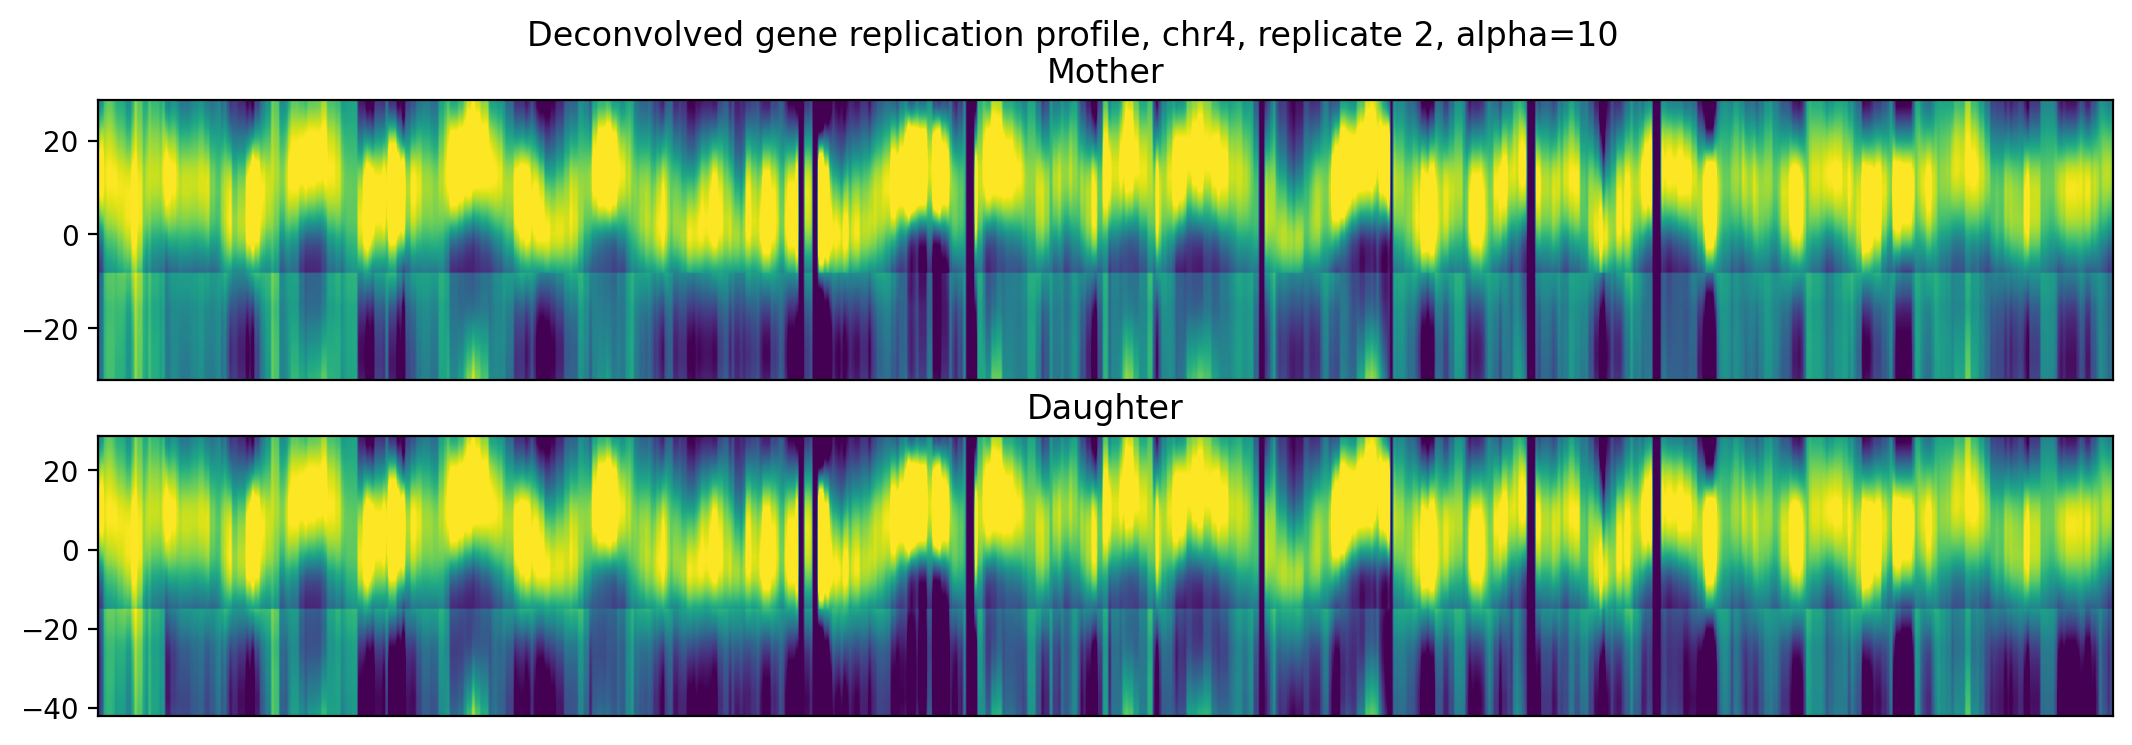

In [162]:
deconv_rep_analysis2.plot_example_alpha_repl_timing(10)

In [ ]:
plt.imshow(deconv_rep_analysis2.chrom_model.deconv_model.H, vmax=1.)